# Figures S32 and S33

This notebook loads the data and produces figure S32 and S33

In [1]:
plotsavedate='20260422'

In [58]:
path_to_analysis_folder = '' # path to analysis folder
data_folder = '' # path to data
path_to_figures_folder = '' # path to figures folder

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn import cluster
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import KMeans
import json
import os
import copy
from matplotlib.colors import LinearSegmentedColormap

from sklearn.neighbors import kneighbors_graph
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# Load Data

In [5]:
os.chdir(path_to_analysis_folder)
from clustering_allUS_preprocessing import ClusteringData


string_cols = ['unique_ID', 'Station Name', 'Street Address', 'Intersection Directions', 'City', 'State_abbr', 'ZIP',  'Status Code', 'EV Network', 'Owner Type Code', 'Open Date',  'EV Pricing', 'Facility Type', 'Groups With Access Code',  'Access Days Time', 'COUNTYNAME', 'State',  'clostestname_PoI', 'clostestname_ind', 'clostestname_topcat', 'utility', 'utilitytype', 'STATEFP']
dtype_dict = {i:'string' for i in string_cols}
dataobj = ClusteringData(savedate=plotsavedate)
combined_df_stations = pd.read_csv(data_folder + '20_level_stations_US_compiled_250415.zip', index_col=0,
                                   dtype=dtype_dict, usecols=dataobj.cols_cluster+['unique_ID', 'State', 'BGFP', 'TRACTFP', 'STATEFP', 'COUNTYFP', 'raw_visit_counts', 'total_pop_byBG'])
dataobj.df = combined_df_stations.copy()
dataobj.clean()
dataobj.normalize()
dataobj.transform(save=False)

# Figure S32: Agglomerative with KNN structure

In [16]:
knn_graph = kneighbors_graph(dataobj.X_std_df, 30, include_self=False)
model = AgglomerativeClustering(linkage='ward', connectivity=knn_graph, n_clusters=8)
model.fit(dataobj.X_std_df)
centers = pd.DataFrame(index=range(8), columns=dataobj.X_std_df.columns)
for i in range(8):
    for col in centers.columns:
        centers.loc[i, col] = dataobj.X_std_df.loc[np.where(model.labels_==i)[0], col].mean(axis=0)

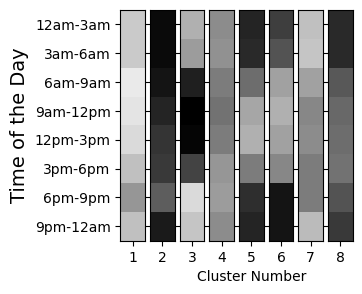

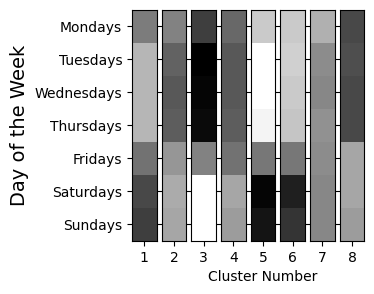

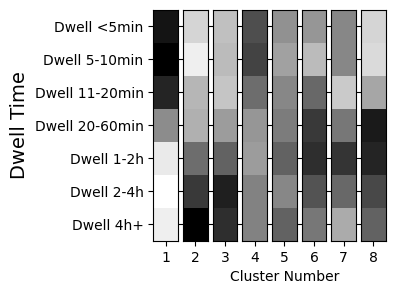

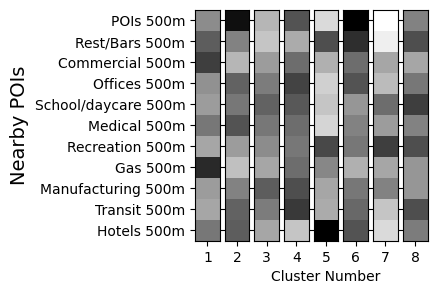

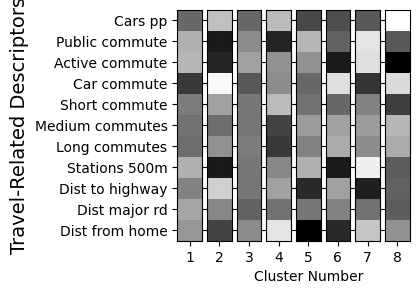

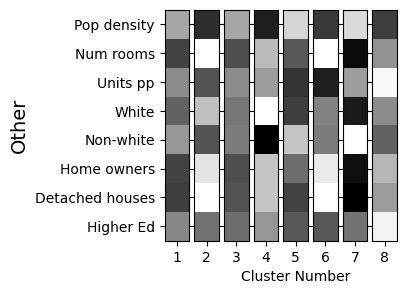

In [63]:
cmap = LinearSegmentedColormap.from_list('Cmap_grey', ['white', 'k'], N=50)

for col_cluster in np.arange(0, 6):
    columns = dataobj.column_ordering[dataobj.column_ordering['Col_Cluster_forDisplay_v2']==col_cluster]['Column'].values
    columns_nice = dataobj.column_ordering[dataobj.column_ordering['Col_Cluster_forDisplay_v2']==col_cluster]['Columns_NiceName'].values
    tmp = centers.loc[:, columns].copy()

    # Plot
    fig, axes = plt.subplots(1, 8, figsize=(3, 3), sharex=False, sharey=True)
    for i in range(8):
        axes[i].imshow(tmp.loc[i, :].T.values.astype(float).reshape((len(columns),1)), cmap=cmap, aspect='auto',
                       vmin=centers.min(axis=1)[i], vmax=centers.max(axis=1)[i])
        axes[i].set_yticks(np.arange(0, len(columns)))
        axes[i].set_yticklabels(columns_nice)
        if i == 0:
            axes[i].set_ylabel(dataobj.section_labels[col_cluster], fontsize=14)
        if i == 4:
            axes[i].set_xlabel('Cluster Number')
    
    for j in range(8):
        axes[j].set_xticks([0])
        axes[j].set_xticklabels([str(j+1)])

    plt.savefig(path_to_figures_folder + 'figureS32_agglomalternative_clustercenters8_columns'+str(col_cluster)+'_'+plotsavedate+'.pdf', bbox_inches='tight')
    plt.savefig(path_to_figures_folder + 'figureS32_agglomalternative_clustercenters8_columns'+str(col_cluster)+'_'+plotsavedate+'.png', bbox_inches='tight', dpi=400)
    plt.show()

# Figure S33: GMM

In [44]:
gm = GaussianMixture(n_components=8, random_state=0).fit(dataobj.X_std_df)
labels = gm.predict(dataobj.X_std_df)
gmcenters = pd.DataFrame(index=range(8), columns=dataobj.X_std_df.columns)
for i in range(8):
    for col in gmcenters.columns:
        gmcenters.loc[i, col] = dataobj.X_std_df.loc[np.where(labels==i)[0], col].mean(axis=0)

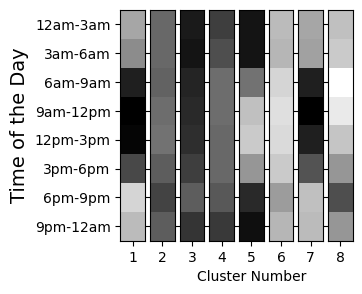

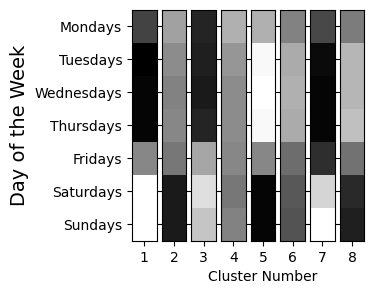

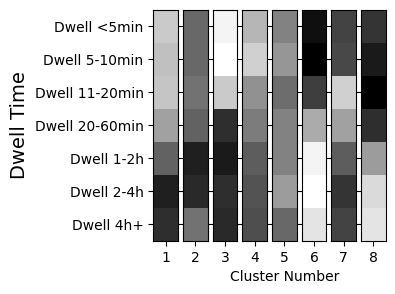

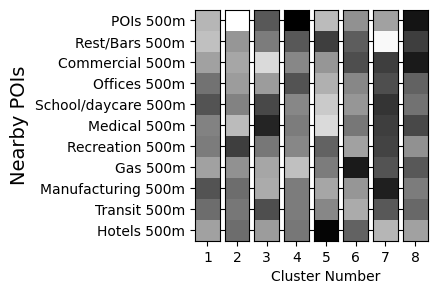

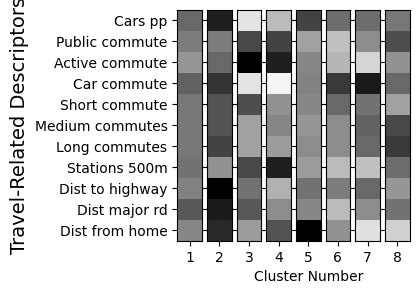

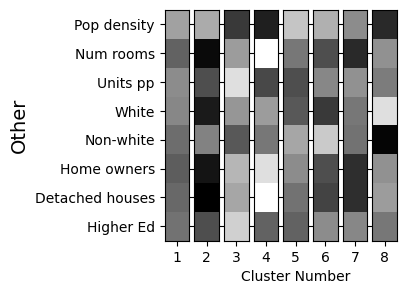

In [64]:
cmap = LinearSegmentedColormap.from_list('Cmap_grey', ['white', 'k'], N=50)

for col_cluster in np.arange(0, 6):
    columns = dataobj.column_ordering[dataobj.column_ordering['Col_Cluster_forDisplay_v2']==col_cluster]['Column'].values
    columns_nice = dataobj.column_ordering[dataobj.column_ordering['Col_Cluster_forDisplay_v2']==col_cluster]['Columns_NiceName'].values
    tmp = gmcenters.loc[:, columns].copy()

    fig, axes = plt.subplots(1, 8, figsize=(3, 3), sharex=False, sharey=True)
    for i in range(8):
        axes[i].imshow(tmp.loc[i, :].T.values.astype(float).reshape((len(columns),1)), cmap=cmap, aspect='auto',
                       vmin=gmcenters.min(axis=1)[i], vmax=gmcenters.max(axis=1)[i])

        axes[i].set_yticks(np.arange(0, len(columns)))
        axes[i].set_yticklabels(columns_nice)
        if i == 0:
            axes[i].set_ylabel(dataobj.section_labels[col_cluster], fontsize=14)
        if i == 4:
            axes[i].set_xlabel('Cluster Number')
    
    for j in range(8):
        axes[j].set_xticks([0])
        axes[j].set_xticklabels([str(j+1)])

    plt.savefig(path_to_figures_folder + 'figureS33_gmmalternative_clustercenters8_columns'+str(col_cluster)+'_'+plotsavedate+'.pdf', bbox_inches='tight')
    plt.savefig(path_to_figures_folder + 'figureS33_gmmalternative_clustercenters8_columns'+str(col_cluster)+'_'+plotsavedate+'.png', bbox_inches='tight', dpi=400)
    plt.show()